In [21]:
import sys,os
sys.path.append('../../')
os.environ["JAX_PLATFORMS"] = "cpu"
import matplotlib.pyplot as plt
import numpy as np
from utils import makefolder,depths,reduce_list_half_preserve_extremes

from geometry import * 

eps = 1E-7
rcpsize = 12
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0

In [7]:
# modelA = 'deepseek'
# modelA = 'llama'
modelA = 'qwen'
modelB = modelA
languages = [
            'english',
            # 'italian',
            # 'spanish',
            # 'german',
            # 'chinese',
            ]

batch_shuffle = 0
centers_list = ['sem']
min_token_length = 3
n_files = 16
batch_size = 100
n_tokens_list = [min_token_length]
avg_flags = [0]
Nbits_list = [0]
match_vars = ['matching']
data_vars = ['sem']
zero_activations_list = [0]
center_A_flags = [0,1]
center_B_flags = [0,1]

[]

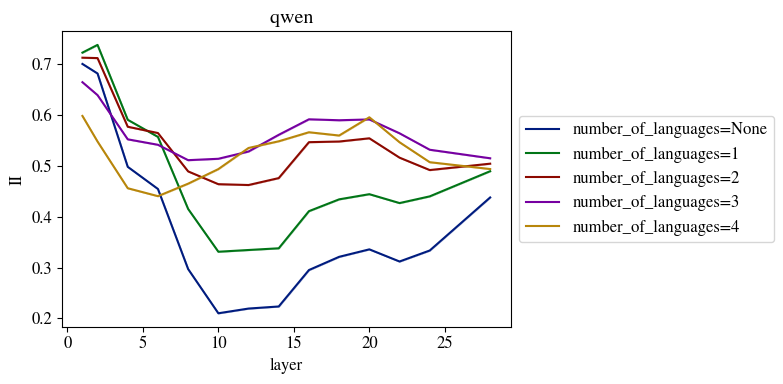

In [10]:
fig,ax = plt.subplots(1,figsize=(8,4))

plot_id = 0
title = ' '

for number_of_languages in [None,1,2,3,4]:
  for zero_id,zero_activations in enumerate(zero_activations_list):
    for center_A_id,center_A_flag in enumerate(center_A_flags):
      for center_B_id,center_B_flag in enumerate(center_B_flags):
        # if zero_activations == 1 and center_A_flag == 0: continue
        if center_A_flag != center_B_flag: 
          continue
        if number_of_languages is None and center_A_flag == 1: 
          continue
        if center_A_flag == 0 and number_of_languages != None:
          continue
        for data_var_id,data_var in enumerate(data_vars):
          for avg_id,avg_tokens in enumerate(avg_flags):
            for centers_id,centers in enumerate(centers_list):
              for match_id,match_var in enumerate(match_vars):
                for Nbits_id,Nbits in enumerate(Nbits_list):
                  for language_id, language in enumerate(languages):
                    for n_tokens in n_tokens_list:
                      output_folder0 = makefolder(base=f'./results/',
                                                  language=language,
                                                  data_var=data_var,
                                                  modelA=modelA,
                                                  modelB=modelB,
                                                  match_var=match_var,
                                                  n_files=n_files,
                                                  min_token_length=min_token_length,
                                                  )
                      II_folder = makefolder(base=output_folder0,
                                                        centers=centers,
                                                        Nbits=Nbits,
                                                        n_tokens=n_tokens,
                                                        avg_tokens=avg_tokens,
                                                        batch_shuffle=batch_shuffle,
                                                        zero_activations=zero_activations,
                                                        center_A_flag=center_A_flag,
                                                        center_B_flag=center_B_flag,
                                                        number_of_languages=number_of_languages,
                                                        )
                      inf_imb = np.load(II_folder + "II.npy")
                      std = np.load(II_folder + "II_jack_std.npy")

                      layers_A = list(range(1,depths[modelA] + 1))
                      layers_B = list(range(1,depths[modelB] + 1))
                      layers = reduce_list_half_preserve_extremes(layers_A)
                      color = colors[plot_id] 
                      # if 0: 
                      #   color = colors[plot_id]
                      #   linestyle = '-'
                      #   label = f'centering_A:{center_A_flag} | centering_B:{center_B_flag}'
                      # if 1: 
                      #   color = colors[plot_id] 
                      #   if zero_activations:
                      #     label = f'{language}, centers_A | centering_B:{center_B_flag}'
                      #   else:
                      #     label = f'{language}, centering_A:{center_A_flag} | centering_B:{center_B_flag}'
                      label = f'{number_of_languages=}'
                      for II_index in range(1):
                        ax.plot(layers,
                                inf_imb[II_index].diagonal(),
                                label=label,
                                linestyle=_linestyles[II_index],
                                color=color,
                                ) 
                        ax.fill_between(layers,
                                        inf_imb[II_index].diagonal() - std[II_index].diagonal(),
                                        inf_imb[II_index].diagonal() + std[II_index].diagonal(),
                                        alpha=0.2,
                                        color=color,
                                        )
                      plot_id += 1

ax.legend()
ax.set_xlabel('layer')
ax.set_ylabel('II')
ax.set_title(title + f' {modelA}')

box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.plot()

### Similarities

In [5]:
# layer_A = 1
# layer_B = 1
# method = 'min'
# sim_folder = makefolder(base=output_folder0+f'similarities/',
#                         create_folder=False,
#                         Nbits=Nbits,
#                         n_tokens=n_tokens,
#                         avg_tokens=avg,
#                         batch_shuffle=batch_shuffle,
#                         layer_A=layer_A,
#                         layer_B=layer_B,
#                         )
# II_fn = build_information_imbalance(k=1)

# A_sim = np.load(os.path.join(sim_folder, "sim_A.npy"))
# B_sim = np.load(os.path.join(sim_folder, "sim_B.npy")) 


In [20]:
from collections import deque

languages = ['chinese', 'german', 'italian', 'spanish']
d = deque(languages)

d.rotate(0)  # Rotate right by 1
print(list(d))  # ['spanish', 'chinese', 'german', 'italian']

d.rotate(1)  # Rotate right by 1
print(list(d))  # ['spanish', 'chinese', 'german', 'italian']

d.rotate(1)  # Rotate left by 2
print(list(d))  # ['german', 'italian', 'spanish', 'chinese']

d.rotate(1)  # Rotate left by 2
print(list(d))  # ['german', 'italian', 'spanish', 'chinese']




['chinese', 'german', 'italian', 'spanish']
['spanish', 'chinese', 'german', 'italian']
['italian', 'spanish', 'chinese', 'german']
['german', 'italian', 'spanish', 'chinese']


In [13]:
from jax import numpy as jnp
import jax
import numpy as np 


group_ids_path = "/home/acevedo/syn-sem/datasets/txt/sem/second/matching/english/group_ids.txt"
all_group_ids = jnp.array(np.loadtxt(group_ids_path).astype(int))
unique_groups_indices = jnp.unique(all_group_ids)

key = jax.random.PRNGKey(999)  # Change seed for different permutations
shuffled_groups = jax.random.permutation(key, unique_groups_indices)
mapping = dict(zip(unique_groups_indices.tolist(), shuffled_groups.tolist()))
_all_group_ids = jnp.array([mapping[g] for g in all_group_ids.tolist()])

print(all_group_ids)
print(_all_group_ids)

[31 37 65 ... 87 19 76]
[ 0 20 68 ... 53 21  3]


In [34]:
print(np.where(all_group_ids==76))
print(np.where(_all_group_ids==3))

(array([ 154,  195,  245,  293,  348,  390,  488,  898,  914,  921,  961,
       1285, 1336, 1429, 1572, 1579, 1599]),)
(array([ 154,  195,  245,  293,  348,  390,  488,  898,  914,  921,  961,
       1285, 1336, 1429, 1572, 1579, 1599]),)


In [24]:
v,c = np.unique(all_group_ids, return_counts=True)
_v,_c = np.unique(_all_group_ids, return_counts=True)

In [28]:
(v == _v).all()

np.True_

In [32]:
c

array([ 4,  4, 13, 16, 40, 31, 26,  7, 32, 14, 26, 21, 11, 13,  5, 12, 15,
        7,  8, 27, 30, 10, 23, 18,  9,  5, 18,  7, 13,  4, 31,  8, 22,  8,
       28, 10, 21,  7,  8, 26,  7, 12, 28,  8, 24, 10,  9, 22, 16,  6,  3,
        5,  4, 21,  6,  3, 15, 24, 37, 74, 16,  6,  5, 16, 41,  5, 15, 27,
        9, 29, 12, 34,  4,  5,  6,  7, 17, 29, 16, 10, 28,  6, 28,  4, 32,
       21,  5, 51, 26, 17, 35, 28, 10,  7, 17,  4])

In [33]:
_c

array([ 8, 32,  4, 17, 15,  5, 16,  6, 29, 10,  9,  7, 16,  4,  6, 37, 10,
        3, 26, 17,  7, 27, 13, 18, 26, 26, 13,  8,  9, 21,  4, 28, 17,  7,
       35, 11,  6,  4,  5, 74, 26, 22,  5, 21,  8, 21, 31, 10,  4, 40, 12,
        9, 24, 51, 14, 23,  7, 15, 18,  6,  5,  4, 16, 28,  3, 16, 41, 32,
        5, 10,  4, 13, 30,  7,  6, 21, 10, 12, 27, 34,  8,  8, 29, 22, 28,
       12,  7,  5, 24,  5,  7, 16, 28, 31, 15, 28])

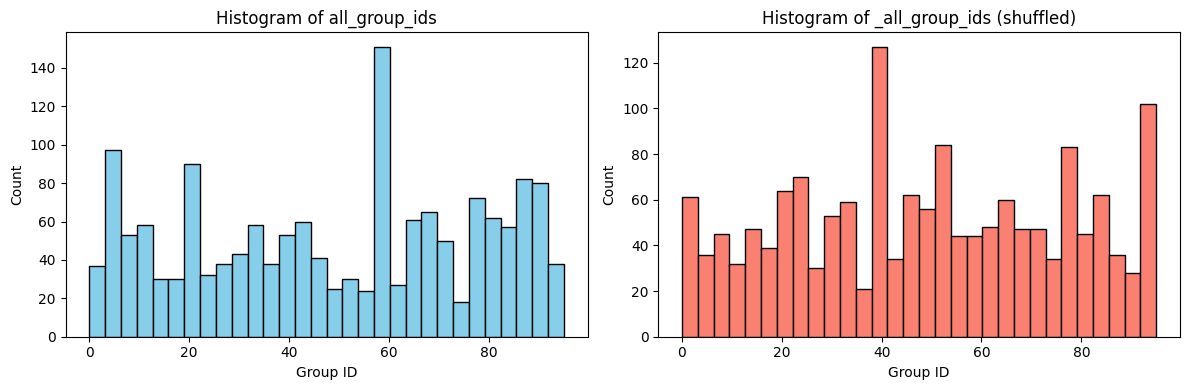

In [18]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].hist(np.array(all_group_ids.sort()), bins=30, color='skyblue', edgecolor='black')
axs[0].set_title('Histogram of all_group_ids')
axs[0].set_xlabel('Group ID')
axs[0].set_ylabel('Count')

axs[1].hist(np.array(_all_group_ids.sort()), bins=30, color='salmon', edgecolor='black')
axs[1].set_title('Histogram of _all_group_ids (shuffled)')
axs[1].set_xlabel('Group ID')
axs[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

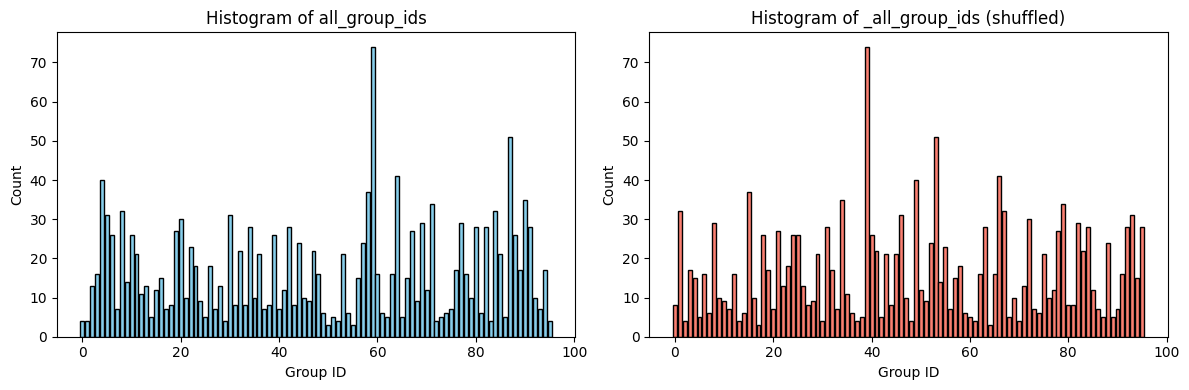

In [21]:
# Use np.unique with return_counts to get counts for each group id
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

group_ids, group_counts = np.unique(np.array(all_group_ids), return_counts=True)
shuffled_ids, shuffled_counts = np.unique(np.array(_all_group_ids), return_counts=True)

axs[0].bar(group_ids, group_counts, color='skyblue', edgecolor='black')
axs[0].set_title('Histogram of all_group_ids')
axs[0].set_xlabel('Group ID')
axs[0].set_ylabel('Count')

axs[1].bar(shuffled_ids, shuffled_counts, color='salmon', edgecolor='black')
axs[1].set_title('Histogram of _all_group_ids (shuffled)')
axs[1].set_xlabel('Group ID')
axs[1].set_ylabel('Count')

plt.tight_layout()
plt.show()